# Моделювання газу твердих сфер

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from random import random

Константи

In [2]:
k = 1.38e-23

Вхідні дані

In [3]:
S = np.pi * 1e-18
H = 1e-9
N = 500
R = 53e-12
M = 1.67e-27
T = 100
G = 9.8
C = 0

Змінні та функції для зручності

In [4]:
# Діаметр основи циліднра
D = 2 * np.sqrt(S / np.pi)

# Випадковий одиничний вектор
def random_k():
    while True:
        k = np.array([random() - 0.5, random() - 0.5, random() - 0.5])
        norm = np.linalg.norm(k)
        if norm > 1e-10:
            return k / norm

In [5]:
# Кінетична енергія від швидкості
def K(v):
    return M*v**2/2

# Швидкість від кінетичної енергії
def v(K):
    return np.sqrt(2*K/M)

In [6]:
# Відбиття частинки від перешкоди
def update_velocity_on_obstacle(p, v):
    return v - 2 * p @ v * p 

In [7]:
# Закон збереження імпульсу
def update_velocities(p1, p2, v1, v2):
    p = (p1 - p2) / np.linalg.norm(p1 - p2)
    d = p @ (v1 -  v2) * p
    v1new = v1 - d
    v2new = v2 + d
    return v1new, v2new

Генерування положення кульок (в межах посудини) і їхні швидкості випадковим чином, але так, 
щоб сума їхніх кінетичних енергії була рівна $3NkT/2$ (N--кількість частинок, T--температура, k--стала Больцмана)

In [8]:
total_enegry = 3 * N * k * T / 2
energies = np.array([(random()) for _ in range(N)])
energies = energies / sum(energies) * total_enegry

In [9]:
def initialize_non_overlapping_positions(N, R, D, H, max_attempts=10000):
    positions = []
    attempts = 0
    while len(positions) < N and attempts < max_attempts:
        attempts += 1
        candidate = np.array([
            (random() - 0.5) * (D - 2 * R),
            (random() - 0.5) * (D - 2 * R),
            (random() - 0.5) * (H - 2 * R)
        ])
        if all(np.linalg.norm(candidate - p) > 2 * R for p in positions):
            positions.append(candidate)
    if len(positions) < N:
        raise RuntimeError(f"Не вдалося ініціалізувати всі {N} частинки без перетинів.")
    return np.array(positions)

In [10]:
# initial_positions = np.array([[(random() - 0.5) * (D-10*R), (random() - 0.5) * (D-10*R), (random() - 0.5) * (H-10*R)] for _ in range(N)])
initial_positions = initialize_non_overlapping_positions(N, R, D,H)
initial_velocities = np.array([random_k() * v(K) for K in energies])

N = 2
initial_positions = np.array([[-1e-6, 0, 0],[1e-6, 0, 0]])
initial_velocities = np.array([[1000, 0, 0], [-1000, 0, 0]])

Оновлення позицій 

In [11]:
def new_positions(positions, velocities, dt):
    return positions + velocities * dt

Перевірка на зіткнення

In [12]:
def detect_collisions(positions):
    collisions_matrix = np.zeros((N, N))
    # for i, p1 in enumerate(positions[:-1]):
    #     for j, p2 in enumerate(positions[i+1:]):
    #         if np.linalg.norm(positions[i] - positions[i + j+1]) <= 2*R:
    #             collisions_matrix[i][i + j+1] = 1
    #             collisions_matrix[i + j+1][i] = 1
    for i in range(N):
        for j in range(i + 1, N):
            if np.linalg.norm(positions[i] - positions[j]) <= 2 * R:
                collisions_matrix[i][j] = 1
                collisions_matrix[j][i] = 1
    return collisions_matrix

In [13]:
def detect_collisions(positions):
    global C
    cell_size = 2 * R
    cell_map = {}
    collisions = np.zeros((N, N))

    def cell_key(pos):
        return tuple((pos // cell_size).astype(int))

    for i, pos in enumerate(positions):
        key = cell_key(pos)
        if key not in cell_map:
            cell_map[key] = []
        cell_map[key].append(i)

    # перевіряємо лише частинки з поточної та суміжних клітинок
    for key, indices in cell_map.items():
        neighbor_offsets = [
            (dx, dy, dz)
            for dx in [-1, 0, 1]
            for dy in [-1, 0, 1]
            for dz in [-1, 0, 1]
        ]
        for offset in neighbor_offsets:
            neighbor_key = tuple(np.add(key, offset))
            if neighbor_key in cell_map:
                for i in indices:
                    for j in cell_map[neighbor_key]:
                        if i < j and np.linalg.norm(positions[i] - positions[j]) <= 2 * R:
                            collisions[i][j] = 1
                            collisions[j][i] = 1
                            C += 1
    return collisions

Оновлення швидкостей

In [14]:
from copy import deepcopy

In [15]:
def process_obstacles(positions, velocities):
    new_velocities = deepcopy(velocities)
    for i, pos in enumerate(positions):
        # Бічні стінки
        if np.linalg.norm(np.array(pos[:-1])) >= D / 2 - R:
            p = np.array([
                -pos[0],
                -pos[1],
                0
            ])
            p /= np.linalg.norm(p)
            new_velocities[i] = update_velocity_on_obstacle(p, new_velocities[i])
            # print(f"particle {i} hit obstacle; normal = {p}, old_v = {velocities[i]}, new_v = {new_velocities[i]}")
        # Кришки
        if abs(pos[2]) >= H / 2 - R:
            p = np.array([
                0,
                0,
                -pos[2]
            ])
            p /= np.linalg.norm(p)
            new_velocities[i] = update_velocity_on_obstacle(p, new_velocities[i])

            # print(f"particle {i} hit obstacle; normal = {p}, old_v = {velocities[i]}, new_v = {new_velocities[i]}")
    return new_velocities


In [16]:
def new_velocities(positions, collisions_matrix, velocities):
    new_velocities = deepcopy(velocities)
    for i in range(N):
        for j in range(N): 
            if collisions_matrix[i][j]:
                new = update_velocities(
                    positions[i],
                    positions[j],
                    new_velocities[i],
                    new_velocities[j])
                # print(f"new: {new}")
                # quit()
                new_velocities[i], new_velocities[j] = new
    # return new_velocities
    return process_obstacles(positions, new_velocities)

### Cимуляція

Параметри симуляції

In [17]:
simulation_time = 1e-10

Симуляція

In [18]:
t = 0
positions = {0: initial_positions}
velocities = {0: initial_velocities}

In [ ]:
while t < simulation_time:
   current_positions = positions[t]
   current_velocities = velocities[t]
   dt = R / 4 / max(np.linalg.norm(v) for v in current_velocities)
   updated_positions = new_positions(current_positions, current_velocities, dt)
   collisions_matrix = detect_collisions(updated_positions)
   updated_velocities = new_velocities(updated_positions, collisions_matrix, current_velocities)
   t += dt
   positions[t] = updated_positions 
   velocities[t] = updated_velocities
   print(f"t: {t}")
   print(1/dt/4*R)
   # print(f"positions: {updated_positions}")
   # print(f"velocities: {updated_velocities}")
   print(f"collisions: {C}")

t: 6.070837175890396e-15
2182.565536862163
collisions: 13
t: 1.2141674351780793e-14
2182.565536862163
collisions: 46
t: 1.8212511527671187e-14
2182.565536862163
collisions: 98
t: 2.4283348703561585e-14
2182.565536862163
collisions: 161
t: 3.0354185879451983e-14
2182.565536862163
collisions: 239
t: 3.576326267280743e-14
2449.5862244507985
collisions: 323
t: 4.068860888387699e-14
2690.1662202386965
collisions: 416
t: 4.605671164199939e-14
2468.2835998158976
collisions: 518
t: 5.142481440012179e-14
2468.2835998158976
collisions: 622
t: 5.679291715824419e-14
2468.2835998158976
collisions: 735
t: 6.216101991636659e-14
2468.2835998158976
collisions: 859
t: 6.718542306006538e-14
2637.1291516718934
collisions: 989
t: 7.255352581818778e-14
2468.2835998158976
collisions: 1116
t: 7.703762932227308e-14
2954.882729162789
collisions: 1245
t: 8.198582059826982e-14
2677.7461219566485
collisions: 1380
t: 8.69609223382432e-14
2663.2621185493394
collisions: 1519
t: 9.160074559376876e-14
2855.712226585482

### а) графік розподілу частинок по швидкостях (розподіл Максвела)

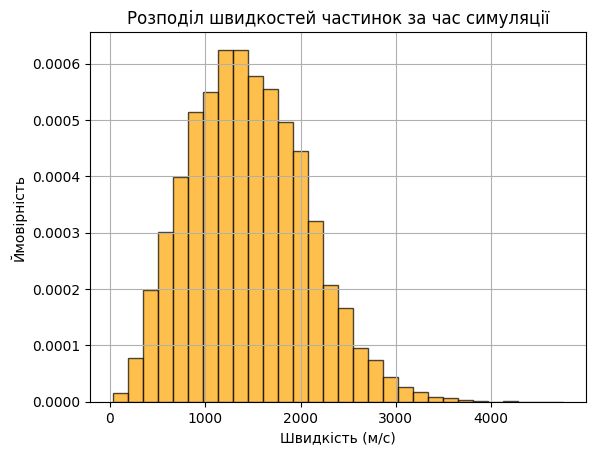

In [ ]:
# Витягуємо всі швидкості за всі моменти часу
all_velocities = [v for vs in velocities.values() for v in vs]
all_speeds = [np.linalg.norm(v) for v in all_velocities]

# Гістограма
plt.hist(all_speeds, bins=30, density=True, alpha=0.7, color='orange', edgecolor='black')
plt.title('Розподіл швидкостей частинок за час симуляції')
plt.xlabel('Швидкість (м/с)')
plt.ylabel('Ймовірність')
plt.grid(True)
plt.show()


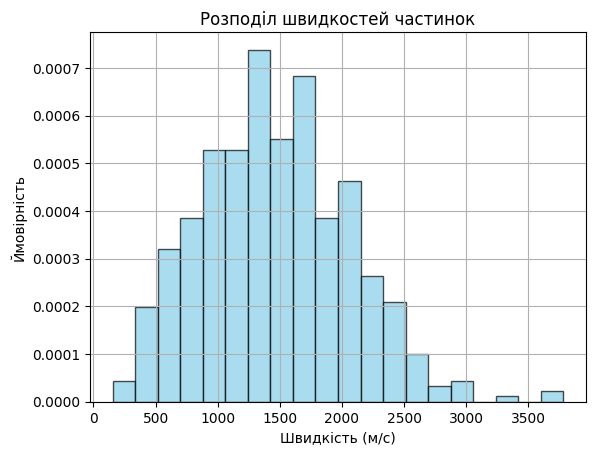

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Витягуємо всі швидкості з останнього моменту часу
final_velocities = list(velocities.values())[-1]

# Обчислюємо модулі (швидкості)
speeds = [np.linalg.norm(v) for v in final_velocities]

# Будуємо гістограму
plt.hist(speeds, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Розподіл швидкостей частинок')
plt.xlabel('Швидкість (м/с)')
plt.ylabel('Ймовірність')
plt.grid(True)
plt.show()


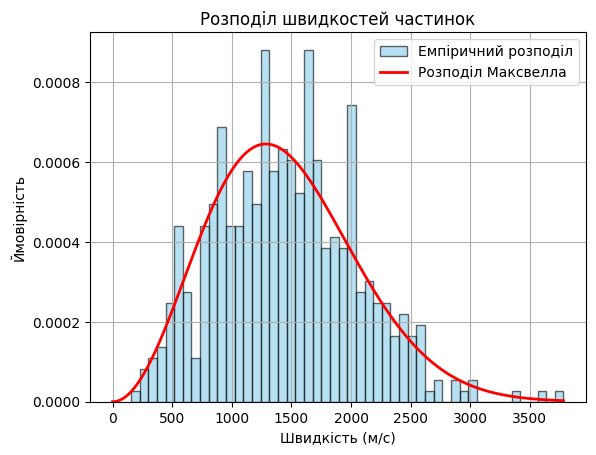

In [ ]:

from scipy.stats import maxwell

# Витягуємо всі швидкості з останнього моменту часу
final_velocities = list(velocities.values())[-1]

# Обчислюємо модулі (швидкості)
speeds = [np.linalg.norm(v) for v in final_velocities]

# Побудова гістограми
count, bins, _ = plt.hist(speeds, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Емпіричний розподіл')

# Теоретичний розподіл Максвелла
x = np.linspace(0, max(speeds), 500)

# Обчислення масштабу для розподілу Максвелла
scale = np.sqrt(k * T / M)

# Побудова аналітичної кривої
plt.plot(x, maxwell.pdf(x, scale=scale), 'r-', linewidth=2, label='Розподіл Максвелла')

# Оформлення графіку
plt.title('Розподіл швидкостей частинок')
plt.xlabel('Швидкість (м/с)')
plt.ylabel('Ймовірність')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2893/1115473371.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P /= np.trapz(P, E)  # нормалізуємо, щоб площа під кривою була 1


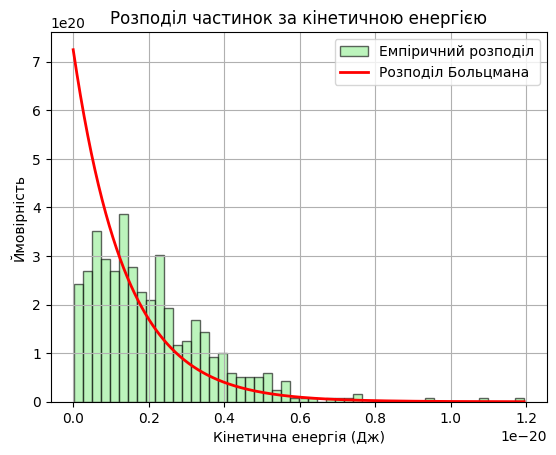

In [ ]:

# Витягуємо всі кінетичні енергії з останнього моменту часу
final_velocities = list(velocities.values())[-1]
energies_sim = [K(np.linalg.norm(v)) for v in final_velocities]  # K(v) вже задана у тебе

# Гістограма енергій
count, bins, _ = plt.hist(energies_sim, bins=50, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Емпіричний розподіл')

# Теоретична крива Больцмана
E = np.linspace(0, max(energies_sim), 500)
P = np.exp(-E / (k * T))
P /= np.trapz(P, E)  # нормалізуємо, щоб площа під кривою була 1

# Побудова теоретичної кривої
plt.plot(E, P, 'r-', label='Розподіл Больцмана', linewidth=2)

# Оформлення графіку
plt.title('Розподіл частинок за кінетичною енергією')
plt.xlabel('Кінетична енергія (Дж)')
plt.ylabel('Ймовірність')
plt.legend()
plt.grid(True)
plt.show()